In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Bronze data
df = pd.read_csv('../data/bronze/raw_credit_data.csv')

# The 'y' target is 'class': 1 = Good, 2 = Bad
# Let's map it to 0 and 1 for easier analysis (1 = Default)
df['target'] = df['class'].map({1: 0, 2: 1})

In [4]:
df

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,67,A143,A152,2,A173,1,A192,A201,1,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,22,A143,A152,1,A173,1,A191,A201,2,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,49,A143,A152,1,A172,2,A191,A201,1,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,45,A143,A153,1,A173,2,A191,A201,1,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,53,A143,A153,2,A173,2,A191,A201,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,31,A143,A152,1,A172,1,A191,A201,1,0
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,40,A143,A152,1,A174,1,A192,A201,1,0
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,38,A143,A152,1,A173,1,A191,A201,1,0
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,23,A143,A153,1,A173,1,A192,A201,2,1


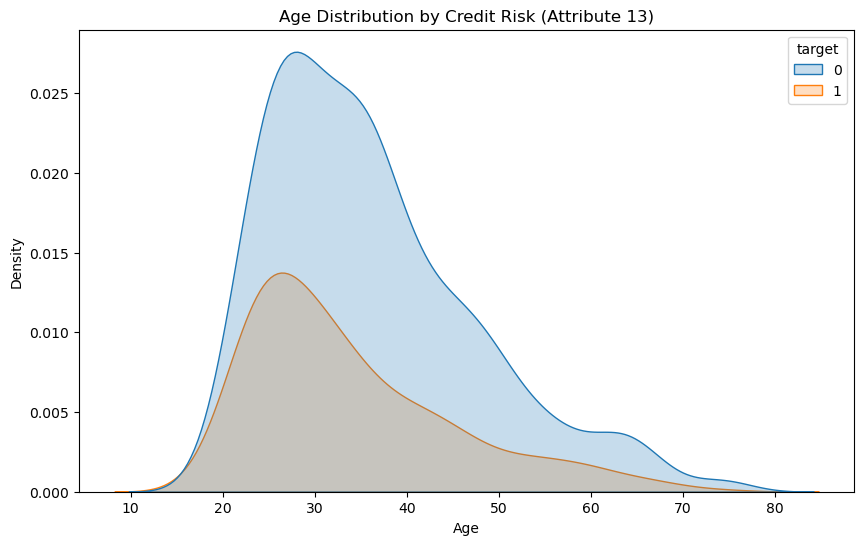

In [5]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Attribute13', hue='target', fill=True)
plt.title('Age Distribution by Credit Risk (Attribute 13)')
plt.xlabel('Age')
plt.show()

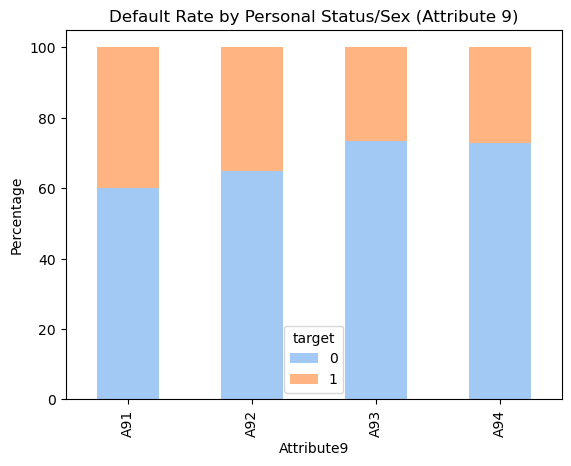

In [6]:
# Cross-tabulate Personal Status (Attribute 9) with Risk
status_risk = pd.crosstab(df['Attribute9'], df['target'], normalize='index') * 100
status_risk.plot(kind='bar', stacked=True, color=['#A1C9F4', '#FFB482'])
plt.title('Default Rate by Personal Status/Sex (Attribute 9)')
plt.ylabel('Percentage')
plt.show()

In [7]:
# Create a copy for analysis
df_encoded = df.copy()

# Convert all 'object' columns to category codes
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Now run your correlation audit
correlations = df_encoded.corr()['Attribute13'].sort_values(ascending=False)
print("Features most correlated with Age (Attribute 13):")
print(correlations.head(10))

Features most correlated with Age (Attribute 13):
Attribute13    1.000000
Attribute15    0.301419
Attribute11    0.266419
Attribute7     0.256227
Attribute16    0.149254
Attribute3     0.147086
Attribute19    0.145259
Attribute18    0.118201
Attribute6     0.084245
Attribute12    0.072606
Name: Attribute13, dtype: float64
